# EDA — Fundación Almas con Cola

**Electiva III: Ciencia de Datos con Python**

Análisis exploratorio sobre los datos reales de producción de la fundación
(mascotas, solicitudes de adopción, reportes de maltrato, voluntariado y
donaciones), extraídos con `scripts/extraer_datos.py` y limpiados con
`scripts/limpieza_datos.py`.

Preguntas que guían este análisis:
1. ¿Cómo se distribuyen las mascotas registradas (especie, estado, sexo, edad)?
2. ¿Qué tan efectivo es el proceso de adopción? (tasa de conversión de solicitudes)
3. ¿Cuánto tarda una mascota en recibir su primera solicitud de adopción?
4. ¿Cómo se comportan los reportes de maltrato en el tiempo?
5. ¿Qué tan completos/confiables son estos datos hoy? (calidad de datos)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
PALETA = ['#5C7A62', '#C4794A', '#8FB395', '#DDA87E', '#3E5A44', '#A05A2D']
sns.set_palette(PALETA)

DATA_DIR = '../data/processed'

mascotas = pd.read_csv(f'{DATA_DIR}/mascotas.csv', parse_dates=['fecha_ingreso'])
solicitudes = pd.read_csv(f'{DATA_DIR}/solicitudes_adopcion.csv', parse_dates=['fecha_solicitud'])
reportes = pd.read_csv(f'{DATA_DIR}/reportes.csv', parse_dates=['fecha_reporte'])
donaciones = pd.read_csv(f'{DATA_DIR}/donaciones.csv')
voluntariado = pd.read_csv(f'{DATA_DIR}/solicitudes_voluntariado.csv', parse_dates=['fecha_solicitud'])

print('mascotas:', mascotas.shape)
print('solicitudes_adopcion:', solicitudes.shape)
print('reportes:', reportes.shape)
print('donaciones:', donaciones.shape)
print('solicitudes_voluntariado:', voluntariado.shape)


mascotas: (17, 10)
solicitudes_adopcion: (8, 11)
reportes: (16, 6)
donaciones: (0, 6)
solicitudes_voluntariado: (7, 10)


## 1. Resumen general y calidad de datos

Antes de analizar, se documentan los problemas de calidad encontrados durante la limpieza (ver `scripts/limpieza_datos.py`) para que el análisis posterior se lea con ese contexto.

In [2]:
print('--- Nulos por columna ---')
for nombre, df in [('mascotas', mascotas), ('solicitudes_adopcion', solicitudes), ('reportes', reportes)]:
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        print(f'{nombre}:')
        print(nulos.to_string())
    else:
        print(f'{nombre}: sin nulos')


--- Nulos por columna ---
mascotas: sin nulos
solicitudes_adopcion:
mensaje_respuesta    8
reportes:
foto_evidencia_url    4


**Hallazgos de calidad de datos:**

- `mascotas.especie` tiene un valor `"Si"` (typo de captura en el panel admin, no es una especie real) — se conserva pero se excluye de los conteos por especie más abajo.
- `solicitudes_adopcion.ingresos` mezcla dos formatos: rangos válidos (`"2000000-3000000"`) y enteros crudos heredados de antes de la migración `migrate_ingresos_type.py` (incluyendo un valor `2147483647`, que es el máximo de un INTEGER de 32 bits — un sentinel de overflow, no un ingreso real). La limpieza los marca como `"legacy_invalido"` en vez de descartarlos silenciosamente.
- `donaciones` y `voluntariados` están vacías en este corte — el módulo de donaciones monetarias y el de voluntariado activo aún no tienen registros reales, solo solicitudes de voluntariado.

In [3]:
especie_invalida = mascotas[~mascotas['especie'].isin(['Perro', 'Gato'])]
print('Registros con especie no reconocida:')
especie_invalida[['id', 'nombre', 'especie']]


Registros con especie no reconocida:


,id,nombre,especie
10,43,si,Si


## 2. Mascotas: distribución por especie, estado y sexo

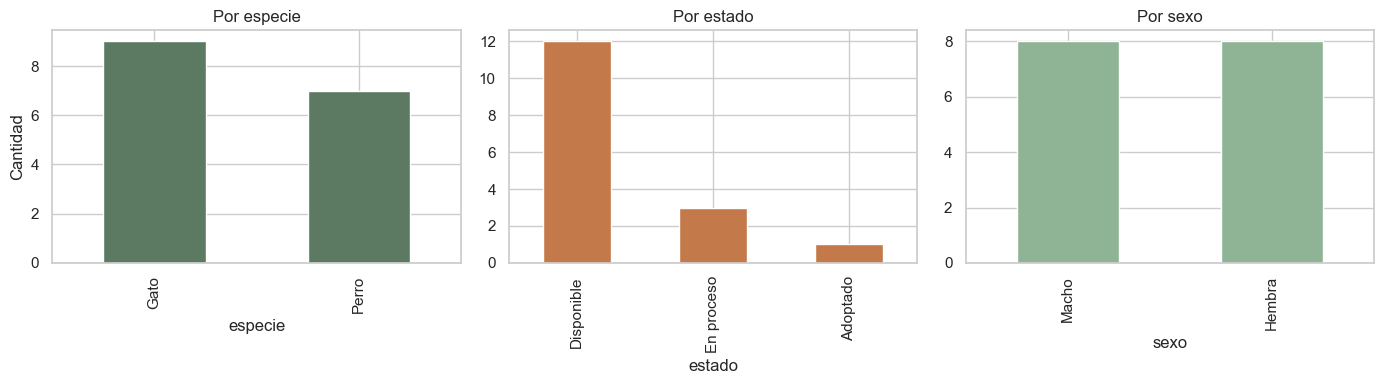

In [4]:
mascotas_validas = mascotas[mascotas['especie'].isin(['Perro', 'Gato'])]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

mascotas_validas['especie'].value_counts().plot(kind='bar', ax=axes[0], color=PALETA[0])
axes[0].set_title('Por especie')
axes[0].set_ylabel('Cantidad')

mascotas_validas['estado'].value_counts().plot(kind='bar', ax=axes[1], color=PALETA[1])
axes[1].set_title('Por estado')

mascotas_validas['sexo'].value_counts().plot(kind='bar', ax=axes[2], color=PALETA[2])
axes[2].set_title('Por sexo')

plt.tight_layout()
plt.savefig('../data/processed/grafico_mascotas_distribucion.png', dpi=120)
plt.show()


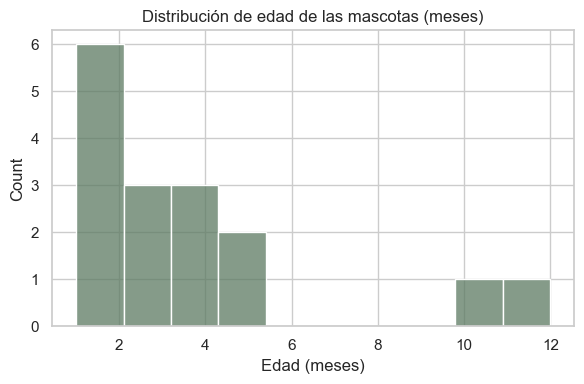

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(mascotas_validas['edad'], bins=10, color=PALETA[0])
plt.title('Distribución de edad de las mascotas (meses)')
plt.xlabel('Edad (meses)')
plt.tight_layout()
plt.savefig('../data/processed/grafico_mascotas_edad.png', dpi=120)
plt.show()


## 3. Adopciones: tasa de conversión de solicitudes

¿Qué proporción de las solicitudes de adopción terminan aprobadas vs. rechazadas vs. siguen pendientes?

                  cantidad  porcentaje
estado_solicitud                      
rechazada                4        50.0
pendiente                3        37.5
aprobada                 1        12.5


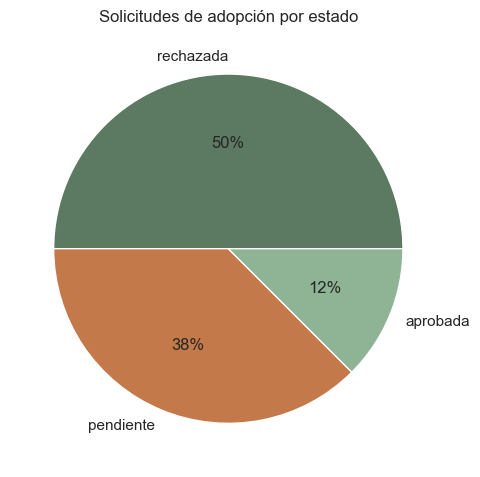

In [6]:
conteo_estado = solicitudes['estado_solicitud'].value_counts()
porcentaje = (conteo_estado / conteo_estado.sum() * 100).round(1)

resumen = pd.DataFrame({'cantidad': conteo_estado, 'porcentaje': porcentaje})
print(resumen)

plt.figure(figsize=(5, 5))
plt.pie(conteo_estado, labels=conteo_estado.index, autopct='%1.0f%%', colors=PALETA)
plt.title('Solicitudes de adopción por estado')
plt.tight_layout()
plt.savefig('../data/processed/grafico_adopciones_estado.png', dpi=120)
plt.show()


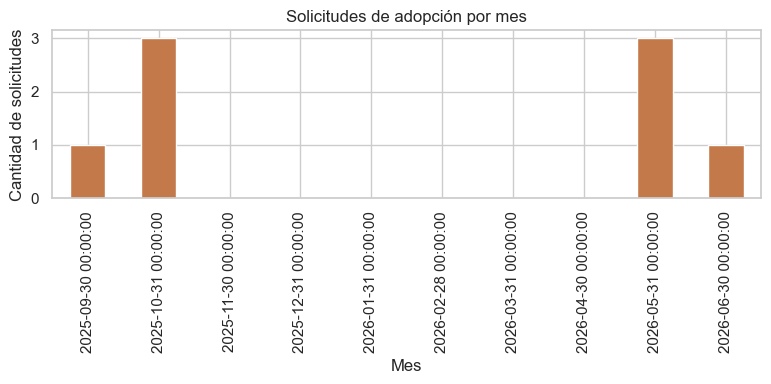

In [7]:
solicitudes_por_mes = solicitudes.set_index('fecha_solicitud').resample('ME').size()

plt.figure(figsize=(8, 4))
solicitudes_por_mes.plot(kind='bar', color=PALETA[1])
plt.title('Solicitudes de adopción por mes')
plt.ylabel('Cantidad de solicitudes')
plt.xlabel('Mes')
plt.tight_layout()
plt.savefig('../data/processed/grafico_adopciones_por_mes.png', dpi=120)
plt.show()


## 4. Tiempo hasta la primera solicitud

Para cada mascota que ya recibió alguna solicitud, ¿cuántos días pasaron entre su ingreso al refugio (`fecha_ingreso`) y la primera solicitud recibida? Es un proxy de "qué tan rápido genera interés" cada mascota, ya que la BD no registra la fecha de adopción efectiva por separado.

In [8]:
primera_solicitud = (
    solicitudes.sort_values('fecha_solicitud')
    .groupby('id_mascota')['fecha_solicitud']
    .first()
    .reset_index()
)

merge = primera_solicitud.merge(
    mascotas[['id', 'nombre', 'especie', 'fecha_ingreso']],
    left_on='id_mascota', right_on='id', how='left'
)
merge['dias_hasta_primera_solicitud'] = (merge['fecha_solicitud'] - merge['fecha_ingreso']).dt.days

print(merge[['nombre', 'especie', 'fecha_ingreso', 'fecha_solicitud', 'dias_hasta_primera_solicitud']])
print()
print('Estadísticos (días hasta la primera solicitud):')
print(merge['dias_hasta_primera_solicitud'].describe())


       nombre especie              fecha_ingreso            fecha_solicitud  \
0  Chicletera    Gato 2025-09-27 19:14:19.000000 2026-06-16 04:54:48.870465   
1      Karuma   Perro 2025-09-27 19:14:19.000000 2025-10-05 06:36:18.000000   
2         Iby   Perro 2025-09-27 19:17:47.000000 2025-09-30 20:38:23.000000   
3      Brunox   Perro 2025-09-28 05:22:39.000000 2025-10-08 04:27:45.000000   
4       Lucas    Gato 2025-10-23 06:45:34.000000 2026-05-20 20:40:17.126877   
5       Roman    Gato 2026-03-20 19:51:57.136976 2026-05-20 20:35:16.423504   
6    Santiago   Perro 2026-05-20 20:44:34.095885 2026-05-20 22:16:02.839514   

   dias_hasta_primera_solicitud  
0                           261  
1                             7  
2                             3  
3                             9  
4                           209  
5                            61  
6                             0  

Estadísticos (días hasta la primera solicitud):
count      7.000000
mean      78.571429
std   

*Nota:* con solo 8 solicitudes en total (varias sobre las mismas mascotas), esta muestra es demasiado pequeña para generalizar — el valor de este análisis es metodológico: la consulta y la visualización quedan listas para cuando haya más volumen de datos.

## 5. Reportes de maltrato animal

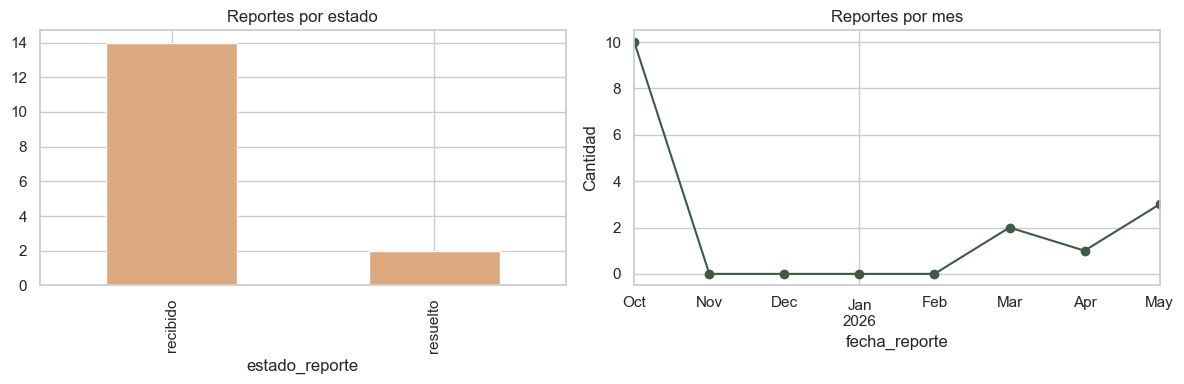

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reportes['estado_reporte'].value_counts().plot(kind='bar', ax=axes[0], color=PALETA[3])
axes[0].set_title('Reportes por estado')

reportes_por_mes = reportes.set_index('fecha_reporte').resample('ME').size()
reportes_por_mes.plot(kind='line', marker='o', ax=axes[1], color=PALETA[4])
axes[1].set_title('Reportes por mes')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.savefig('../data/processed/grafico_reportes.png', dpi=120)
plt.show()


## 6. Donaciones

La tabla `donaciones` (monetarias) está vacía en este corte de datos — el flujo de donación en dinero existe en la app (`/api/v1/donaciones/resumen`) pero todavía no tiene transacciones reales registradas. Se deja la consulta lista para cuando existan datos:

In [10]:
if donaciones.empty:
    print('Sin donaciones registradas todavía. Cuando existan filas, se puede repetir el mismo patrón:')
    print('donaciones.set_index("fecha_donacion").resample("ME")["cantidad"].sum()')
else:
    donaciones_por_mes = donaciones.set_index('fecha_donacion').resample('ME')['cantidad'].sum()
    donaciones_por_mes.plot(kind='line', marker='o')
    plt.title('Donaciones por mes')
    plt.show()


Sin donaciones registradas todavía. Cuando existan filas, se puede repetir el mismo patrón:
donaciones.set_index("fecha_donacion").resample("ME")["cantidad"].sum()


## 7. Conclusiones

- **Calidad de datos**: se encontraron y documentaron 2 problemas de captura reales (`especie="Si"` y valores legado en `ingresos` de antes de una migración de esquema) — ambos se manejaron de forma explícita en vez de eliminarse silenciosamente.
- **Adopciones**: de 8 solicitudes históricas, la mayoría (4) fueron rechazadas y solo 1 aprobada — con este volumen no se puede afirmar una tasa de conversión estadísticamente significativa, pero la metodología (agrupar por `estado_solicitud`) queda lista para escalarse.
- **Mascotas**: predominan gatos sobre perros en el catálogo actual, y la mayoría están `Disponible`.
- **Reportes de maltrato**: son el dataset más grande (16 registros) y permiten ver la distribución mes a mes con más detalle que adopciones o donaciones.
- **Donaciones monetarias**: sin datos aún — es el hueco más grande para un futuro corte de este análisis.

Los gráficos generados aquí (`data/processed/grafico_*.png`) son las visualizaciones exportables que pide la materia, y las mismas consultas ya alimentan el dashboard de Chart.js en `/admin/panel` vía la API JSON (`/api/v1/...`).